# MICrONS20 structural circuit visualisation

This is a **read-only analysis notebook** for the frozen CAVE-first structural circuit.

It does not modify canonical artifacts. It visualises:

- the selected 20 neurons and their processed CAVE-derived morphologies;
- one neuron at a time in interactive 3D, including compartment labels and audit markers;
- the complete 20-cell microcircuit in the shared MICrONS coordinate frame;
- recurrent connectivity as a directed graph;
- the 20 × 20 synaptic-contact matrix;
- incoming contacts from sources outside the selected 20;
- synapse-placement QC by target compartment.

Important terminology: `outside_selected20` means *outside the simulated 20-cell subset*. It does **not** yet mean biologically extrinsic input.

The functions in this notebook are intentionally exploratory. Once the visualisations are accepted, move reusable functions into `src/microns20/visualization.py` and keep this notebook as a thin caller.


## 1. Setup and canonical artifacts

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import morphio
import networkx as nx
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

from collections import defaultdict, deque

from microns20.config import find_project_root, load_config

project_root = find_project_root()
config = load_config(project_root)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)

project_root


PosixPath('<PROJECT_ROOT>')

In [2]:
manifest = pd.read_parquet(
    project_root / "data/processed/final20_manifest.parquet"
)

functional_mappings = pd.read_parquet(
    project_root / "data/processed/final20_functional_mappings.parquet"
)

morphology_manifest = pd.read_parquet(
    project_root / "data/processed/morphologies/manifest.parquet"
)

intrinsic_synapses = pd.read_parquet(
    project_root / "data/processed/connectivity/intrinsic_synapses.parquet"
)

outside20_synapses = pd.read_parquet(
    project_root / "data/processed/connectivity/incoming_external_synapses.parquet"
)

radius_events = pd.read_parquet(
    project_root / "results/tables/radius_normalization_events.parquet"
)

transition_events = pd.read_parquet(
    project_root / "results/tables/compartment_transition_events.parquet"
)

point_map = pd.read_parquet(
    project_root / "data/interim/morphologies/cave_to_simulation_point_map.parquet"
)

synapse_qc = pd.read_parquet(
    project_root / "results/tables/synapse_mapping_qc.parquet"
)

assert len(manifest) == 20
assert len(intrinsic_synapses) == 54
assert len(outside20_synapses) == 44282

print("Selected neurons:", len(manifest))
print("Intrinsic contacts:", len(intrinsic_synapses))
print("Outside-selected20 contacts:", len(outside20_synapses))
print("Unique outside-selected20 roots:", outside20_synapses["pre_pt_root_id"].nunique())


Selected neurons: 20
Intrinsic contacts: 54
Outside-selected20 contacts: 44282
Unique outside-selected20 roots: 29991


## 2. Resolve morphology paths and recurrent pairs

In [3]:
morphology_index = (
    morphology_manifest[
        ["model_node_id", "nucleus_id", "pt_root_id", "simulation_morphology"]
    ]
    .sort_values("model_node_id")
    .set_index("model_node_id")
)

root_to_model = (
    manifest[["model_node_id", "pt_root_id"]]
    .drop_duplicates()
    .set_index("pt_root_id")["model_node_id"]
)

intrinsic = intrinsic_synapses.copy()
intrinsic["source_model_node_id"] = intrinsic["pre_pt_root_id"].map(root_to_model)
intrinsic["target_model_node_id"] = intrinsic["post_pt_root_id"].map(root_to_model)

if intrinsic[
    ["source_model_node_id", "target_model_node_id"]
].isna().any().any():
    raise ValueError("An intrinsic synapse could not be mapped to the frozen 20.")

intrinsic["source_model_node_id"] = intrinsic["source_model_node_id"].astype(int)
intrinsic["target_model_node_id"] = intrinsic["target_model_node_id"].astype(int)

recurrent_pairs = (
    intrinsic
    .groupby(
        ["source_model_node_id", "target_model_node_id"],
        as_index=False,
    )
    .agg(n_synapses=("id", "nunique"))
    .sort_values(
        ["source_model_node_id", "target_model_node_id"]
    )
    .reset_index(drop=True)
)

print("Directed recurrent pairs:", len(recurrent_pairs))
display(recurrent_pairs)


Directed recurrent pairs: 38


,source_model_node_id,target_model_node_id,n_synapses
0,0,13,1
1,0,14,1
2,0,18,2
3,1,2,1
4,1,16,1
5,2,1,1
6,2,9,1
7,3,0,2
8,3,9,1
9,3,11,1


## 3. Helpers for morphology rendering

The processed SWCs already preserve the **global MICrONS coordinate frame**. Therefore this notebook does **not** apply the rotation/translation logic used by the older OBI/BMTK visualisation notebook.


In [4]:
SECTION_NAMES = {
    morphio.SectionType.axon: "axon",
    morphio.SectionType.basal_dendrite: "dendrite",
    morphio.SectionType.apical_dendrite: "apical",
    morphio.SectionType.undefined: "undefined",
}

SWC_TYPE_NAMES = {
    1: "soma",
    2: "axon",
    3: "dendrite",
    4: "apical",
}


def morphology_path(model_node_id):
    relative = morphology_index.loc[int(model_node_id), "simulation_morphology"]
    path = project_root / relative
    if not path.is_file():
        raise FileNotFoundError(path)
    return path


def load_processed_swc(model_node_id):
    return pd.read_csv(
        morphology_path(model_node_id),
        sep=r"\s+",
        comment="#",
        header=None,
        names=["id", "type", "x", "y", "z", "radius", "parent"],
    )


def morphology_lines_by_compartment(
    model_node_id,
    max_points_per_section=80,
):
    morph = morphio.Morphology(str(morphology_path(model_node_id)))
    arrays = {}

    for section in morph.iter():
        compartment = SECTION_NAMES.get(section.type, str(section.type))
        points = np.asarray(section.points, dtype=float)

        if len(points) < 2:
            continue

        if len(points) > max_points_per_section:
            indices = np.linspace(
                0,
                len(points) - 1,
                max_points_per_section,
            ).astype(int)
            points = points[indices]

        xs, ys, zs = arrays.setdefault(
            compartment,
            ([], [], []),
        )

        xs.extend(points[:, 0])
        ys.extend(points[:, 1])
        zs.extend(points[:, 2])

        xs.append(None)
        ys.append(None)
        zs.append(None)

    return morph, arrays


## 4. Inspect one neuron in 2D

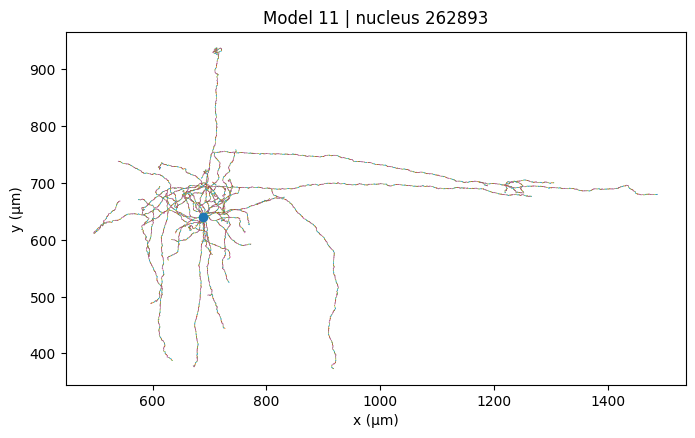

In [5]:
def plot_neuron_2d(model_node_id, plane="xy"):
    axes = {
        "xy": ("x", "y"),
        "xz": ("x", "z"),
        "yz": ("y", "z"),
    }
    if plane not in axes:
        raise ValueError(f"plane must be one of {sorted(axes)}")

    a, b = axes[plane]
    swc = load_processed_swc(model_node_id)
    by_id = swc.set_index("id")

    fig, ax = plt.subplots(figsize=(8, 8))

    for row in swc.itertuples(index=False):
        if int(row.parent) == -1:
            continue

        parent = by_id.loc[int(row.parent)]

        ax.plot(
            [float(parent[a]), float(getattr(row, a))],
            [float(parent[b]), float(getattr(row, b))],
            linewidth=0.5,
        )

    soma = swc.loc[swc["type"].eq(1), ["x", "y", "z"]]
    soma_center = soma.mean(axis=0)

    ax.scatter(
        [float(soma_center[a])],
        [float(soma_center[b])],
        s=35,
        zorder=10,
    )

    ax.set_aspect("equal")
    ax.set_xlabel(f"{a} (µm)")
    ax.set_ylabel(f"{b} (µm)")

    meta = manifest.set_index("model_node_id").loc[int(model_node_id)]
    ax.set_title(
        f"Model {model_node_id} | nucleus {int(meta['nucleus_id'])}"
    )

    plt.show()


plot_neuron_2d(11, plane="xy")


## 5. Interactive 3D view of one neuron

This view separates axon, dendrite and apical compartments where those labels exist. Audit markers can also be displayed for radius-normalised points and non-soma compartment transitions.


In [20]:
def plot_neuron_3d(
    model_node_id,
    max_points_per_section=100,
    show_audit_markers=True,
):
    model_node_id = int(model_node_id)
    morph, arrays = morphology_lines_by_compartment(
        model_node_id,
        max_points_per_section=max_points_per_section,
    )

    meta = manifest.set_index("model_node_id").loc[model_node_id]
    swc = load_processed_swc(model_node_id).set_index("id")

    fig = go.Figure()

    for compartment, (xs, ys, zs) in arrays.items():
        fig.add_trace(
            go.Scatter3d(
                x=xs,
                y=ys,
                z=zs,
                mode="lines",
                line=dict(width=3),
                name=compartment,
            )
        )

    soma_points = np.asarray(morph.soma.points, dtype=float)
    soma_center = soma_points.mean(axis=0)

    fig.add_trace(
        go.Scatter3d(
            x=[soma_center[0]],
            y=[soma_center[1]],
            z=[soma_center[2]],
            mode="markers",
            marker=dict(size=8),
            name="soma",
        )
    )

    if show_audit_markers:
        model_radius = radius_events.loc[
            radius_events["model_node_id"].eq(model_node_id)
        ]

        if not model_radius.empty:
            mapped_radius = model_radius.merge(
                point_map.loc[
                    point_map["model_node_id"].eq(model_node_id),
                    ["raw_point_id", "simulation_point_id"],
                ],
                on="raw_point_id",
                how="left",
                validate="one_to_one",
            )

            radius_points = swc.loc[
                mapped_radius["simulation_point_id"].astype(int)
            ]

            fig.add_trace(
                go.Scatter3d(
                    x=radius_points["x"],
                    y=radius_points["y"],
                    z=radius_points["z"],
                    mode="markers",
                    marker=dict(size=6, symbol="diamond"),
                    name="radius-normalised point",
                    text=[
                        f"raw point {raw}<br>0 → {new:.3f} µm"
                        for raw, new in zip(
                            mapped_radius["raw_point_id"],
                            mapped_radius["normalized_radius_um"],
                        )
                    ],
                    hovertemplate="%{text}<extra></extra>",
                )
            )

        model_transitions = transition_events.loc[
            transition_events["model_node_id"].eq(model_node_id)
            & transition_events["parent_type"].ne(1)
            & transition_events["child_type"].ne(1)
        ]

        if not model_transitions.empty:
            transition_points = swc.loc[
                model_transitions["child_point_id"].astype(int)
            ]

            fig.add_trace(
                go.Scatter3d(
                    x=transition_points["x"],
                    y=transition_points["y"],
                    z=transition_points["z"],
                    mode="markers",
                    marker=dict(size=8, symbol="x"),
                    name="non-soma type transition",
                    text=[
                        f"{parent} → {child}"
                        for parent, child in zip(
                            model_transitions["parent_compartment"],
                            model_transitions["child_compartment"],
                        )
                    ],
                    hovertemplate="%{text}<extra></extra>",
                )
            )

    fig.update_layout(
        title=(
            f"Model {model_node_id} | nucleus {int(meta['nucleus_id'])} | "
            f"{meta['microns_mtype']}"
        ),
        scene=dict(
            xaxis_title="x (µm)",
            yaxis_title="y (µm)",
            zaxis_title="z (µm)",
            aspectmode="data",
        ),
        width=950,
        height=850,
    )

    return fig


plot_neuron_3d(4).show()


In [16]:
# how many axon entry points exist (places where a type-2 axon point has a parent that is not axon)
# whether all axon points form one connected component.

def audit_single_neuron_axon(swc_df):
    """
    swc_df columns expected:
    id, type, x, y, z, radius, parent

    SWC types:
    1 = soma
    2 = axon
    3 = dendrite
    4 = apical
    """

    swc = swc_df.copy()
    swc["id"] = swc["id"].astype(int)
    swc["parent"] = swc["parent"].astype(int)
    swc["type"] = swc["type"].astype(int)

    by_id = swc.set_index("id")

    axon = swc[swc["type"] == 2].copy()

    print("Total axon points:", len(axon))

    # axon entry points = axon point whose parent is not axon
    entry_rows = []

    for row in axon.itertuples(index=False):
        if row.parent == -1:
            entry_rows.append(
                {
                    "axon_point_id": row.id,
                    "parent_id": row.parent,
                    "parent_type": None,
                    "reason": "root",
                }
            )
        elif row.parent not in by_id.index:
            entry_rows.append(
                {
                    "axon_point_id": row.id,
                    "parent_id": row.parent,
                    "parent_type": None,
                    "reason": "missing_parent",
                }
            )
        else:
            parent_type = int(by_id.loc[row.parent, "type"])
            if parent_type != 2:
                entry_rows.append(
                    {
                        "axon_point_id": row.id,
                        "parent_id": row.parent,
                        "parent_type": parent_type,
                        "reason": "parent_not_axon",
                    }
                )

    entry_df = pd.DataFrame(entry_rows)
    print("Number of axon entry points:", len(entry_df))
    display(entry_df)

    # build undirected graph only among axon points
    axon_ids = set(axon["id"].tolist())
    graph = defaultdict(list)

    for row in axon.itertuples(index=False):
        if row.parent in axon_ids:
            graph[row.id].append(row.parent)
            graph[row.parent].append(row.id)
        else:
            graph[row.id]  # ensure node exists

    # connected components
    visited = set()
    components = []

    for node in axon_ids:
        if node in visited:
            continue
        q = deque([node])
        visited.add(node)
        comp = []

        while q:
            cur = q.popleft()
            comp.append(cur)
            for nb in graph[cur]:
                if nb not in visited:
                    visited.add(nb)
                    q.append(nb)

        components.append(comp)

    components = sorted(components, key=len, reverse=True)

    print("Number of connected axon components:", len(components))
    print("Component sizes:", [len(c) for c in components[:10]])

    return entry_df, components

swc = load_processed_swc(0)
entry_df, components = audit_single_neuron_axon(swc)

Total axon points: 4466
Number of axon entry points: 1


,axon_point_id,parent_id,parent_type,reason
0,2,1,1,parent_not_axon


Number of connected axon components: 1
Component sizes: [4466]


## 6. Interactive 3D view of the complete 20-cell circuit

Every processed morphology is already in the same MICrONS coordinate frame. Recurrent edges below are schematic soma-to-soma lines; exact synapses remain stored in the connectivity artifacts.


In [26]:
def plot_circuit_3d_with_opacity_slider(
    initial_neurite_opacity=0.22,
    recurrent_opacity=0.65,
):
    fig = plot_circuit_3d()
    n_cells = len(manifest)
    neurite_indices = list(range(0, 2 * n_cells, 2))
    soma_indices = list(range(1, 2 * n_cells, 2))

    def trace_opacities(neurite_opacity):
        return [
            float(neurite_opacity) if index in neurite_indices
            else 1.0 if index in soma_indices
            else float(recurrent_opacity)
            for index in range(len(fig.data))
        ]

    initial_opacities = trace_opacities(initial_neurite_opacity)
    for index, opacity in enumerate(initial_opacities):
        fig.data[index].opacity = opacity

    slider_steps = []
    for opacity in [0.05, 0.10, 0.15, 0.22, 0.30, 0.40, 0.55, 0.75, 1.0]:
        slider_steps.append(
            dict(
                label=f"{opacity:.2f}",
                method="update",
                args=[{"opacity": trace_opacities(opacity)}],
            )
        )

    for menu in fig.layout.updatemenus:
        menu.x = 0.0
        menu.y = 1.04
        menu.xanchor = "left"
        menu.yanchor = "bottom"

    fig.update_layout(
        autosize=True,
        width=None,
        height=900,
        margin=dict(l=10, r=10, t=100, b=105),
        scene=dict(
            domain=dict(x=[0.0, 1.0], y=[0.12, 0.96]),
            aspectmode="cube",
        ),
        sliders=[
            dict(
                active=3,
                x=0.15,
                y=0.0,
                len=0.70,
                currentvalue={"prefix": "Neurite opacity: "},
                pad={"t": 12},
                steps=slider_steps,
            )
        ],
    )

    return fig


plot_circuit_3d_with_opacity_slider().show()

## 7. Directed recurrent graph in biological XY space

In [9]:
def plot_recurrent_graph_spatial():
    indexed_manifest = manifest.set_index("model_node_id")
    fig = go.Figure()

    for pair in recurrent_pairs.itertuples(index=False):
        source = indexed_manifest.loc[int(pair.source_model_node_id)]
        target = indexed_manifest.loc[int(pair.target_model_node_id)]

        fig.add_trace(
            go.Scatter(
                x=[source["soma_x_um"], target["soma_x_um"]],
                y=[source["soma_y_um"], target["soma_y_um"]],
                mode="lines",
                line=dict(width=1 + np.log1p(int(pair.n_synapses))),
                showlegend=False,
                hovertemplate=(
                    f"M{int(pair.source_model_node_id)} → "
                    f"M{int(pair.target_model_node_id)}<br>"
                    f"{int(pair.n_synapses)} contact(s)"
                    "<extra></extra>"
                ),
            )
        )

    fig.add_trace(
        go.Scatter(
            x=indexed_manifest["soma_x_um"],
            y=indexed_manifest["soma_y_um"],
            mode="markers+text",
            text=[f"M{i}" for i in indexed_manifest.index],
            textposition="top center",
            marker=dict(size=12),
            customdata=np.column_stack(
                [
                    indexed_manifest["nucleus_id"],
                    indexed_manifest["microns_mtype"],
                ]
            ),
            hovertemplate=(
                "Model %{text}<br>"
                "nucleus %{customdata[0]}<br>"
                "m-type %{customdata[1]}"
                "<extra></extra>"
            ),
            name="selected neurons",
        )
    )

    fig.update_layout(
        title="Directed recurrent graph in MICrONS XY soma coordinates",
        xaxis_title="x (µm)",
        yaxis_title="y (µm)",
        yaxis=dict(scaleanchor="x", scaleratio=1),
        width=950,
        height=800,
    )

    return fig


plot_recurrent_graph_spatial().show()


## 8. Graph-topology view

In [10]:
def plot_recurrent_graph_topology(seed=42):
    graph = nx.DiGraph()
    graph.add_nodes_from(manifest["model_node_id"].astype(int))

    for pair in recurrent_pairs.itertuples(index=False):
        graph.add_edge(
            int(pair.source_model_node_id),
            int(pair.target_model_node_id),
            weight=int(pair.n_synapses),
        )

    positions = nx.spring_layout(
        graph,
        seed=seed,
        weight="weight",
    )

    fig = go.Figure()

    for source, target, data in graph.edges(data=True):
        x0, y0 = positions[source]
        x1, y1 = positions[target]

        fig.add_trace(
            go.Scatter(
                x=[x0, x1],
                y=[y0, y1],
                mode="lines",
                line=dict(width=1 + np.log1p(data["weight"])),
                showlegend=False,
                hovertemplate=(
                    f"M{source} → M{target}<br>"
                    f"{data['weight']} contact(s)"
                    "<extra></extra>"
                ),
            )
        )

    node_ids = sorted(graph.nodes)
    node_x = [positions[node][0] for node in node_ids]
    node_y = [positions[node][1] for node in node_ids]

    in_degree = np.array([graph.in_degree(node) for node in node_ids])
    out_degree = np.array([graph.out_degree(node) for node in node_ids])

    fig.add_trace(
        go.Scatter(
            x=node_x,
            y=node_y,
            mode="markers+text",
            text=[f"M{node}" for node in node_ids],
            textposition="top center",
            marker=dict(
                size=12 + 2 * (in_degree + out_degree),
            ),
            customdata=np.column_stack([in_degree, out_degree]),
            hovertemplate=(
                "%{text}<br>"
                "in-degree %{customdata[0]}<br>"
                "out-degree %{customdata[1]}"
                "<extra></extra>"
            ),
            name="neurons",
        )
    )

    fig.update_layout(
        title="Recurrent graph topology",
        xaxis_visible=False,
        yaxis_visible=False,
        width=900,
        height=800,
    )

    return fig


plot_recurrent_graph_topology().show()


## 9. 20 × 20 recurrent synaptic-contact matrix

In [11]:
node_ids = sorted(manifest["model_node_id"].astype(int).tolist())

contact_matrix = (
    recurrent_pairs
    .pivot(
        index="source_model_node_id",
        columns="target_model_node_id",
        values="n_synapses",
    )
    .reindex(index=node_ids, columns=node_ids)
    .fillna(0)
    .astype(int)
)

fig = px.imshow(
    contact_matrix,
    labels={
        "x": "Target model node",
        "y": "Source model node",
        "color": "Synaptic contacts",
    },
    text_auto=True,
    aspect="equal",
    title="MICrONS20 recurrent synaptic-contact matrix",
)

fig.show()


## 10. Contacts from outside the selected 20

These are anatomical inputs from positive CAVE presynaptic roots not belonging to the frozen 20. They should not yet be interpreted as biologically extrinsic input.


In [12]:
outside20_by_target = (
    outside20_synapses
    .groupby("model_node_id")
    .agg(
        n_contacts=("id", "nunique"),
        n_source_roots=("pre_pt_root_id", "nunique"),
    )
    .reset_index()
    .merge(
        manifest[
            ["model_node_id", "nucleus_id", "microns_mtype"]
        ],
        on="model_node_id",
        how="left",
        validate="one_to_one",
    )
)

display(outside20_by_target)

fig = px.bar(
    outside20_by_target,
    x="model_node_id",
    y="n_contacts",
    hover_data=[
        "n_source_roots",
        "nucleus_id",
        "microns_mtype",
    ],
    labels={
        "model_node_id": "Model node",
        "n_contacts": "Outside-selected20 synaptic contacts",
    },
    title="Incoming contacts from sources outside the selected 20",
)

fig.show()


,model_node_id,n_contacts,n_source_roots,nucleus_id,microns_mtype
0,0,2867,2464,260303,L4a
1,1,1774,1522,260621,L4b
2,2,1462,1263,260625,L4b
3,3,1966,1738,260628,L4a
4,4,1479,1221,260648,L4b
5,5,2488,2053,260689,L4b
6,6,2423,2015,262547,L4a
7,7,1482,1258,262654,L4b
8,8,1289,1045,262698,L4b
9,9,1766,1561,262810,L4b


## 11. Synapse-placement QC by target compartment

In [13]:
all_mapped_inputs = pd.concat(
    [
        intrinsic.assign(input_class="intrinsic"),
        outside20_synapses.assign(input_class="outside_selected20"),
    ],
    ignore_index=True,
)

all_mapped_inputs["target_compartment"] = (
    all_mapped_inputs["afferent_section_type"]
    .map(SWC_TYPE_NAMES)
)

placement_summary = (
    all_mapped_inputs
    .groupby(["input_class", "target_compartment"])
    .agg(
        n_synapses=("id", "nunique"),
        median_distance_um=("synapse_to_section_distance_um", "median"),
        p95_distance_um=(
            "synapse_to_section_distance_um",
            lambda values: values.quantile(0.95),
        ),
        max_distance_um=("synapse_to_section_distance_um", "max"),
    )
    .reset_index()
)

display(placement_summary)

fig = px.box(
    all_mapped_inputs,
    x="target_compartment",
    y="synapse_to_section_distance_um",
    points=False,
    labels={
        "target_compartment": "Mapped target compartment",
        "synapse_to_section_distance_um": "Synapse-to-section distance (µm)",
    },
    title="Synapse-placement distance by mapped target compartment",
)

fig.show()


,input_class,target_compartment,n_synapses,median_distance_um,p95_distance_um,max_distance_um
0,intrinsic,axon,2,0.933813,0.969400,0.973354
1,intrinsic,dendrite,52,1.528961,3.022514,3.458088
2,outside_selected20,axon,257,0.795532,1.675458,6.128953
3,outside_selected20,dendrite,42829,1.436277,3.130735,9.886757
4,outside_selected20,soma,1196,4.522828,8.998544,20.437995


In [14]:
worst_placements = (
    all_mapped_inputs
    .sort_values(
        "synapse_to_section_distance_um",
        ascending=False,
    )
    .head(50)
)

display(
    worst_placements[
        [
            "id",
            "input_class",
            "model_node_id",
            "target_nucleus_id",
            "afferent_section_id",
            "afferent_section_pos",
            "afferent_section_type",
            "target_compartment",
            "synapse_to_section_distance_um",
            "synapse_to_cave_skeleton_vertex_distance_um",
        ]
    ]
)


,id,input_class,model_node_id,target_nucleus_id,afferent_section_id,afferent_section_pos,afferent_section_type,target_compartment,synapse_to_section_distance_um,synapse_to_cave_skeleton_vertex_distance_um
35975,181851812,outside_selected20,14,296680,0,0.192428,1,soma,20.437995,20.689488
38560,188700618,outside_selected20,14,296680,0,0.383706,1,soma,18.446455,18.486506
29491,173626397,outside_selected20,15,296750,0,0.681558,1,soma,14.079650,14.191229
32194,175476267,outside_selected20,19,299068,0,0.391263,1,soma,13.963880,14.008704
7385,143305899,outside_selected20,0,260303,0,0.138900,1,soma,13.344146,13.942313
32191,175475993,outside_selected20,19,299068,0,0.391263,1,soma,13.166243,13.213772
10316,146919503,outside_selected20,5,260689,0,0.400963,1,soma,12.305529,12.346729
13372,152407991,outside_selected20,2,260625,0,0.367927,1,soma,11.764555,11.837492
10311,146919142,outside_selected20,5,260689,0,0.302712,1,soma,11.364243,11.540266
32192,175476158,outside_selected20,19,299068,0,0.488350,1,soma,10.987168,10.987801
